## Exploratory Data Analysis: The Arsenal Story

## Step 1 — Imports & Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
%matplotlib inline

#Plot Style
sns.set_theme(style = 'whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Colour Pallettes
ARSENAL_RED   = '#EF0107'
ARSENAL_NAVY  = '#063672'
ARSENAL_GOLD  = '#9C824A'
LIGHT_GREY    = '#D3D3D3'

STAKES_PALETTE = {'High Stakes' : ARSENAL_RED, 'Normal':ARSENAL_GOLD}

print('✅ All imports and style settings loaded')

✅ All imports and style settings loaded


##  Load Data

In [18]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROC_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

# Main Arsenal Dataset
ars = pd.read_csv(PROC_DATA_DIR / 'arsenal_processed.csv')
ars['date'] = pd.to_datetime(ars['date'])
ars= ars.sort_values('date').reset_index(drop = True)

# Pre arteta baseline
pre = pd.read_csv(RAW_DATA_DIR / 'arsenal_pre_arteta_raw.csv')
pre['date'] = pd.to_datetime(pre['date'])
pre = pre.sort_values('date').reset_index(drop = True)

# Drop Index summary table
drop_idx = pd.read_csv(PROC_DATA_DIR / 'drop_index.csv', index_col = 0)

print(f'Arsenal (Arteta era) : {ars.shape}')
print(f'Arsenal (pre-Arteta) : {pre.shape}')
print(f'Drop Index table     : {drop_idx.shape}')
print(f'\nArteta seasons : {sorted(ars["season"].unique())}')
print(f'Pre-Arteta     : {sorted(pre["season"].unique())}')

Arsenal (Arteta era) : (266, 36)
Arsenal (pre-Arteta) : (76, 11)
Drop Index table     : (4, 14)

Arteta seasons : [np.int64(1920), np.int64(2021), np.int64(2122), np.int64(2223), np.int64(2324), np.int64(2425), np.int64(2526)]
Pre-Arteta     : [np.int64(1718), np.int64(1819)]


## Quick Data Overview

In [19]:
#Match count per season
print("Matches per season: ")
print(ars.groupby('season').size())
print(f'\nTotal: {len(ars)} matches')
print(f'High stakes: {ars["is_high_stakes"].sum()} ({ars["is_high_stakes"].mean()*100:.1f}%)')
print(f'Normal:      {(~ars["is_high_stakes"]).sum()} ({(~ars["is_high_stakes"]).mean()*100:.1f}%)')

Matches per season: 
season
1920    38
2021    38
2122    38
2223    38
2324    38
2425    38
2526    38
dtype: int64

Total: 266 matches
High stakes: 104 (39.1%)
Normal:      162 (60.9%)


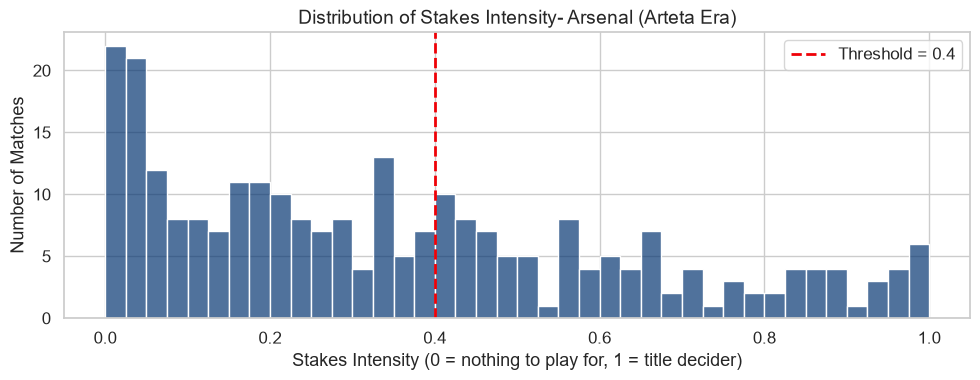

In [26]:
#Stakes intensity distribution

fig, ax = plt.subplots(figsize = (10, 4))

sns.histplot(data=ars, x = 'stakes_intensity',bins = 40, color= ARSENAL_NAVY, alpha = 0.7, ax = ax)

ax.axvline(x=0.4, color = ARSENAL_RED, linestyle='--', linewidth = 2, label = 'Threshold = 0.4')

ax.set_title('Distribution of Stakes Intensity- Arsenal (Arteta Era)',fontsize = 14)
ax.set_xlabel('Stakes Intensity (0 = nothing to play for, 1 = title decider)')
ax.set_ylabel('Number of Matches')
ax.legend()

plt.tight_layout()
plt.show()

In [27]:
#High stakes count per season- check the split makes sense

stakes_by_season = (
    ars.groupby('season')['is_high_stakes']
    .agg(['sum','count'])
    .rename(columns={'sum': 'high_stakes','count':'total'})
)
stakes_by_season['normal'] = stakes_by_season['total'] - stakes_by_season['high_stakes']
stakes_by_season['pct_high'] = (stakes_by_season['high_stakes'] / stakes_by_season['total'] * 100).round(1)

print('High-stakes matches per season: ')
print(stakes_by_season)

High-stakes matches per season: 
        high_stakes  total  normal  pct_high
season                                      
1920              9     38      29      23.7
2021              8     38      30      21.1
2122             16     38      22      42.1
2223             18     38      20      47.4
2324             17     38      21      44.7
2425             17     38      21      44.7
2526             19     38      19      50.0


## SECTION A - Pre-Arteta Baseline (2017-19)

## Chart A1 - "The Starting Point"